# SENTINEL-WM | Phase 3-5 - Model Zoo & Benchmark

The whole model zoo is trained by `python -m sentinel_wm.research all`
(or `00_complete_pipeline.ipynb`). **This notebook reads the results** and
renders the comparison, so it is fast and always reflects the latest run.

| group | models |
|---|---|
| classical ML | LogReg, RandomForest, ExtraTrees, HistGB, sklearn-MLP, LinearSVC, kNN, GaussianNB, **XGBoost**, **LightGBM** - each `window` and `__seq` |
| neural seq | **MLP**, **LSTM**, **GRU**, **TCN** |
| graph | **GAT** (from scratch, per-window host graphs) |
| world model | **SENTINEL-WM** = Temporal Transformer + probabilistic STN + K-step MC rollout |

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C
RB = '../research/benchmarks'

## 3.1  Full scoreboard (test split, FPR-calibrated threshold)

In [3]:
bf = pd.read_csv(f'{RB}/benchmark_full.csv')
cols = ['model','family','input','f1','precision','recall','fpr','auroc',
        'brier_k1','ece_k1','mean_lead_time_s','detection_rate',
        'progression_acc','params','infer_ms']
bf[cols].sort_values('f1', ascending=False).round(3)

,model,family,input,f1,precision,recall,fpr,auroc,brier_k1,ece_k1,mean_lead_time_s,detection_rate,progression_acc,params,infer_ms
0,persistence,reference,sequence,0.770,0.939,0.653,0.012,0.820,0.036,0.036,0.0,0.000,NaN,NaN,0.000
1,gat,graph,sequence,0.687,0.765,0.624,0.056,0.894,0.064,0.033,10.0,0.061,0.860,246820.0,0.239
2,xgboost__seq,classical,sequence,0.678,0.794,0.591,0.045,0.906,0.054,0.032,10.0,0.166,NaN,NaN,0.022
3,random_forest__seq,classical,sequence,0.648,0.798,0.545,0.040,0.896,0.062,0.032,10.0,0.141,NaN,NaN,0.268
4,hist_gradient_boosting__seq,classical,sequence,0.643,0.777,0.549,0.046,0.912,0.068,0.067,10.0,0.163,NaN,NaN,0.025
5,lstm,nn,sequence,0.638,0.769,0.545,0.048,0.874,0.087,0.080,10.0,0.128,0.837,241572.0,0.009
6,SENTINEL-WM,world_model,sequence,0.622,0.631,0.614,0.104,0.854,0.081,0.059,10.0,0.217,0.854,803882.0,0.014
7,mlp_sklearn__seq,classical,sequence,0.601,0.767,0.494,0.044,0.813,0.074,0.036,10.0,0.096,NaN,NaN,0.011
8,xgboost,classical,window,0.601,0.783,0.487,0.039,0.869,0.077,0.048,10.0,0.144,NaN,NaN,0.017
9,extra_trees,classical,window,0.590,0.760,0.482,0.044,0.850,0.081,0.082,10.0,0.157,NaN,NaN,0.177


## 3.2  Forecast-horizon F1 - does accuracy hold as the horizon grows?

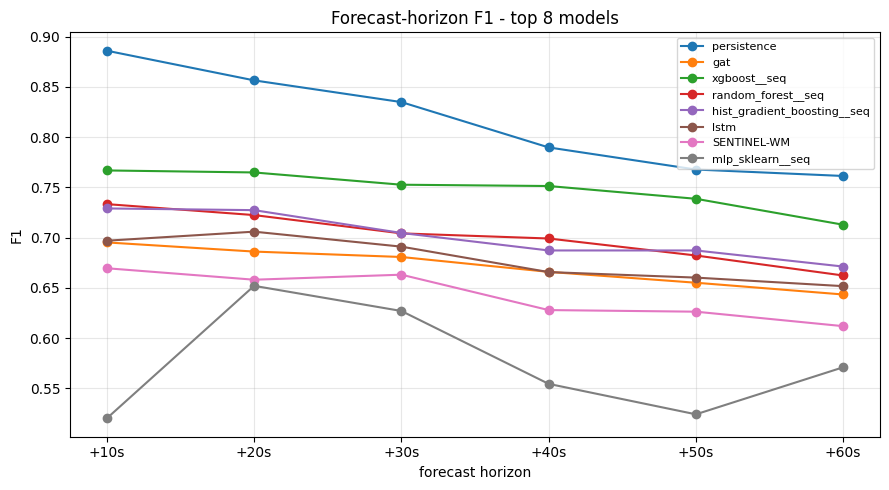

In [4]:
ph = pd.read_csv(f'{RB}/per_horizon_f1.csv').set_index('model')
top = bf.sort_values('f1', ascending=False)['model'].head(8).tolist()
ax = ph.loc[[m for m in top if m in ph.index]].T.plot(figsize=(9,5), marker='o')
ax.set_ylabel('F1'); ax.set_xlabel('forecast horizon'); ax.grid(alpha=.3)
ax.set_title('Forecast-horizon F1 - top 8 models'); ax.legend(fontsize=8); plt.tight_layout()

## 3.3  Lead time & episode detection

In [5]:
lt = pd.read_csv(f'{RB}/leadtime.csv').sort_values('detection_rate', ascending=False)
lt.round(3)

,model,mean_lead_time_s,median_lead_time_s,detection_rate,false_alarm_rate,episodes_warned,episodes
6,SENTINEL-WM,10.0,10.0,0.217,0.036,68,313
12,tcn,10.0,10.0,0.214,0.016,67,313
14,gru,10.0,10.0,0.201,0.017,63,313
19,gaussian_nb,10.0,10.0,0.176,0.064,55,313
2,xgboost__seq,10.0,10.0,0.166,0.009,52,313
4,hist_gradient_boosting__seq,10.0,10.0,0.163,0.004,51,313
9,extra_trees,10.0,10.0,0.157,0.003,49,313
13,hist_gradient_boosting,10.0,10.0,0.150,0.000,47,313
20,logistic_regression,10.0,10.0,0.144,0.010,45,313
8,xgboost,10.0,10.0,0.144,0.002,45,313


## 3.4  Pre-rendered figures from the research run

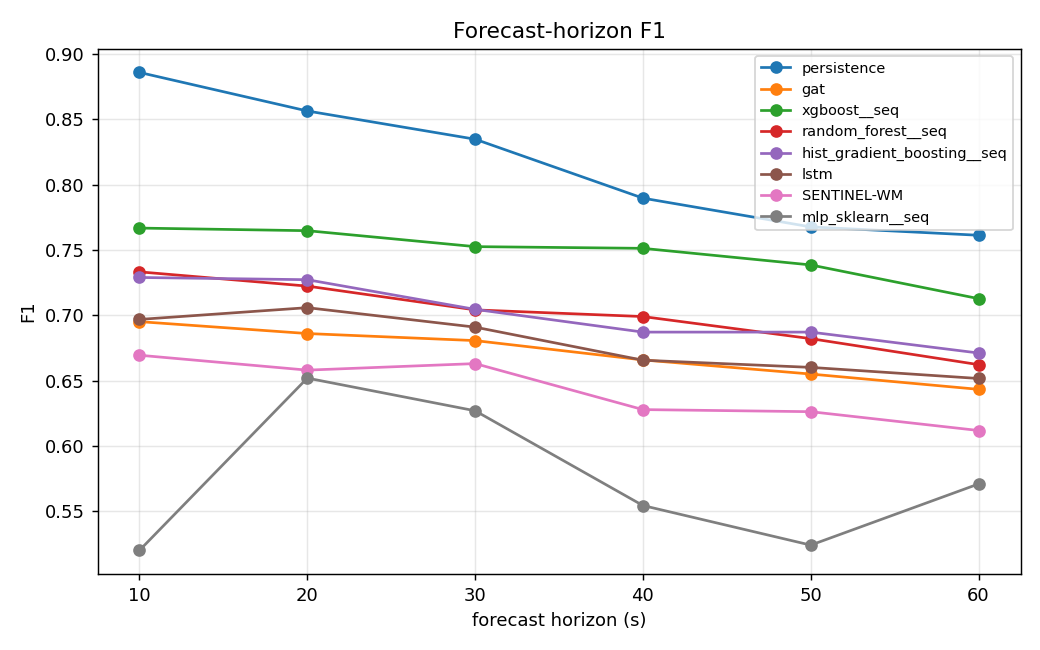

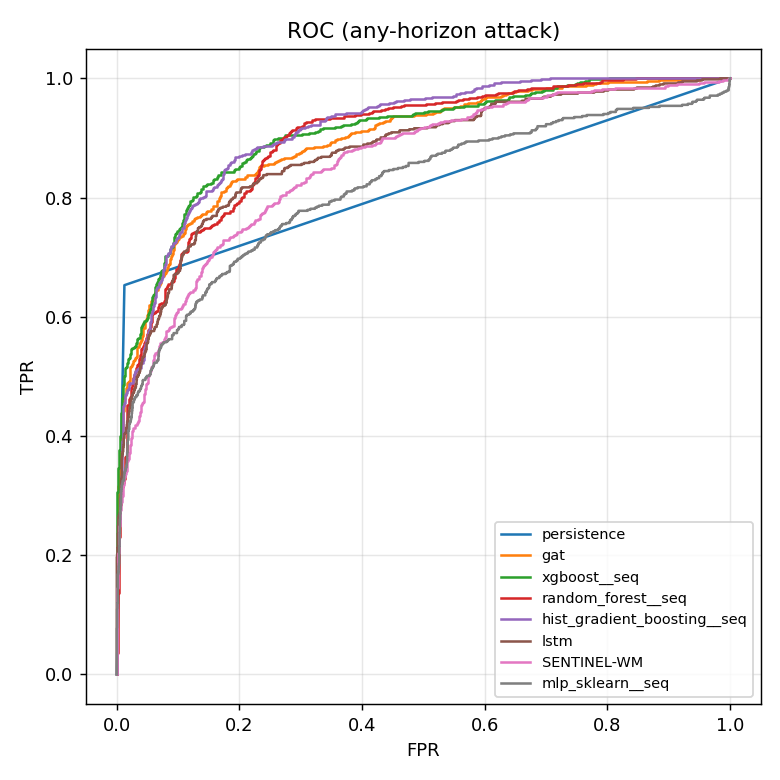

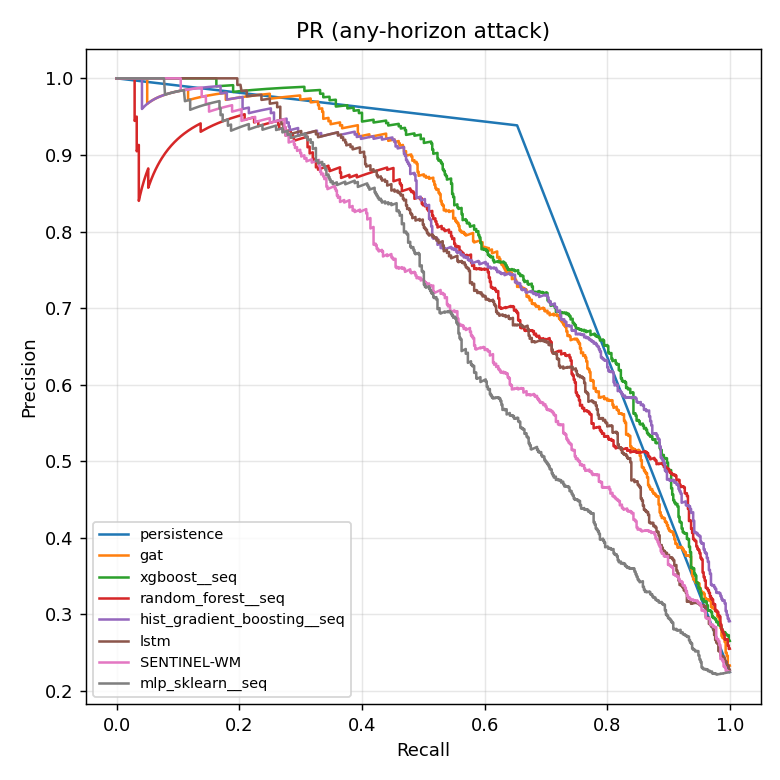

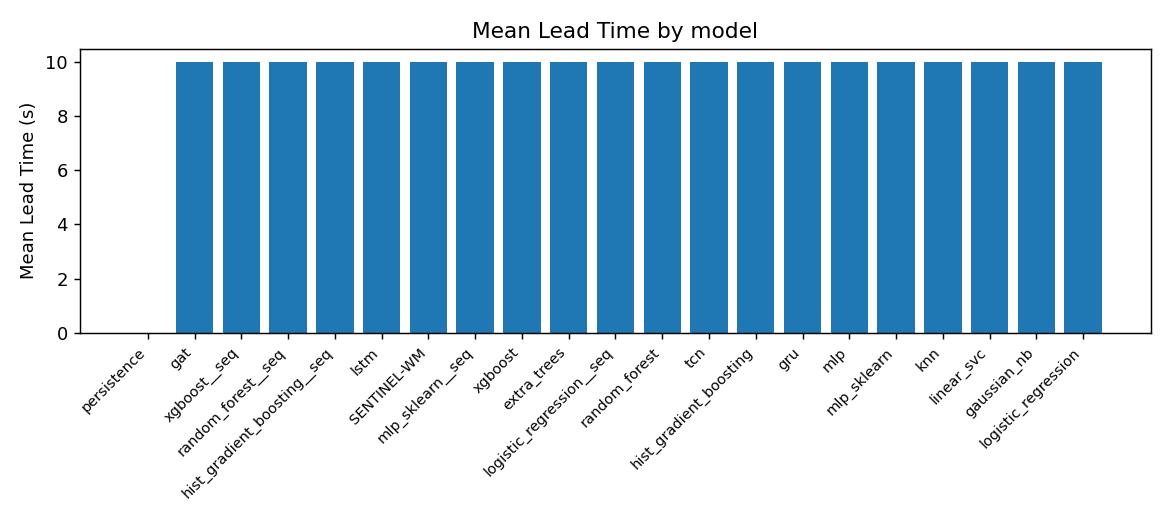

In [6]:
from IPython.display import Image, display
for f in ['horizon_f1','roc','pr','lead_time']:
    p = f'../research/figures/{f}.png'
    import os
    if os.path.exists(p): display(Image(p))

## 3.5  The ranked markdown table

In [7]:
from IPython.display import Markdown
Markdown(open(f'{RB}/benchmark.md').read())

# SENTINEL-WM - Full Model Benchmark

Test split = **Friday** (2602 sequences, 22.5% attack). Threshold FPR-calibrated on validation (Thursday).

## Ranked by any-horizon F1

| Model | Family | In | F1 | Prec | Rec | FPR | AUROC | Brier | ECE | MLT (s) | Detect | FA | ProgAcc | Params | infer ms |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| persistence | reference | sequence | 0.770 | 0.939 | 0.653 | 0.012 | 0.820 | 0.036 | 0.036 | 0.0 | 0.00 | 0.000 | - | - | 0.000 |
| gat | graph | sequence | 0.687 | 0.765 | 0.624 | 0.056 | 0.894 | 0.064 | 0.033 | 10.0 | 0.06 | 0.042 | 0.860 | 246,820 | 0.239 |
| xgboost__seq | classical | sequence | 0.678 | 0.794 | 0.591 | 0.045 | 0.906 | 0.054 | 0.032 | 10.0 | 0.17 | 0.009 | - | - | 0.022 |
| random_forest__seq | classical | sequence | 0.648 | 0.797 | 0.545 | 0.040 | 0.896 | 0.062 | 0.032 | 10.0 | 0.14 | 0.002 | - | - | 0.268 |
| hist_gradient_boosting__seq | classical | sequence | 0.643 | 0.777 | 0.549 | 0.046 | 0.912 | 0.068 | 0.067 | 10.0 | 0.16 | 0.004 | - | - | 0.025 |
| lstm | nn | sequence | 0.638 | 0.769 | 0.545 | 0.048 | 0.874 | 0.087 | 0.080 | 10.0 | 0.13 | 0.013 | 0.837 | 241,572 | 0.009 |
| SENTINEL-WM | world_model | sequence | 0.622 | 0.631 | 0.614 | 0.104 | 0.854 | 0.081 | 0.059 | 10.0 | 0.22 | 0.036 | 0.854 | 803,882 | 0.015 |
| mlp_sklearn__seq | classical | sequence | 0.601 | 0.767 | 0.494 | 0.044 | 0.813 | 0.074 | 0.036 | 10.0 | 0.10 | 0.017 | - | - | 0.011 |
| xgboost | classical | window | 0.601 | 0.783 | 0.487 | 0.039 | 0.869 | 0.077 | 0.048 | 10.0 | 0.14 | 0.002 | - | - | 0.017 |
| extra_trees | classical | window | 0.590 | 0.760 | 0.482 | 0.044 | 0.850 | 0.081 | 0.082 | 10.0 | 0.16 | 0.003 | - | - | 0.177 |
| logistic_regression__seq | classical | sequence | 0.576 | 0.740 | 0.472 | 0.048 | 0.854 | 0.144 | 0.161 | 10.0 | 0.09 | 0.030 | - | - | 0.007 |
| random_forest | classical | window | 0.565 | 0.766 | 0.448 | 0.040 | 0.854 | 0.074 | 0.044 | 10.0 | 0.14 | 0.001 | - | - | 0.215 |
| tcn | nn | sequence | 0.551 | 0.640 | 0.484 | 0.079 | 0.843 | 0.101 | 0.101 | 10.0 | 0.21 | 0.016 | 0.820 | 168,036 | 0.005 |
| hist_gradient_boosting | classical | window | 0.548 | 0.775 | 0.424 | 0.036 | 0.860 | 0.106 | 0.117 | 10.0 | 0.15 | 0.000 | - | - | 0.021 |
| gru | nn | sequence | 0.548 | 0.641 | 0.479 | 0.078 | 0.830 | 0.107 | 0.107 | 10.0 | 0.20 | 0.017 | 0.805 | 186,532 | 0.006 |
| mlp | nn | sequence | 0.541 | 0.652 | 0.462 | 0.071 | 0.843 | 0.133 | 0.128 | 10.0 | 0.14 | 0.024 | 0.798 | 402,724 | 0.003 |
| mlp_sklearn | classical | window | 0.521 | 0.772 | 0.393 | 0.034 | 0.809 | 0.079 | 0.025 | 10.0 | 0.08 | 0.006 | - | - | 0.006 |
| knn | classical | window | 0.430 | 0.764 | 0.299 | 0.027 | 0.781 | 0.096 | 0.037 | 10.0 | 0.06 | 0.008 | - | - | 1.267 |
| linear_svc | classical | window | 0.382 | 0.653 | 0.270 | 0.042 | 0.782 | 0.191 | 0.291 | 10.0 | 0.12 | 0.008 | - | - | 0.001 |
| gaussian_nb | classical | window | 0.382 | 0.435 | 0.340 | 0.128 | 0.719 | 0.172 | 0.145 | 10.0 | 0.18 | 0.064 | - | - | 0.003 |
| logistic_regression | classical | window | 0.377 | 0.601 | 0.275 | 0.053 | 0.781 | 0.170 | 0.231 | 10.0 | 0.14 | 0.010 | - | - | 0.001 |

## Forecast-horizon F1 (holds up as the horizon grows?)

| Model | +10s | +20s | +30s | +40s | +50s | +60s |
|---|---|---|---|---|---|---|
| persistence | 0.886 | 0.856 | 0.835 | 0.790 | 0.768 | 0.761 |
| gat | 0.695 | 0.686 | 0.681 | 0.666 | 0.655 | 0.643 |
| xgboost__seq | 0.767 | 0.765 | 0.753 | 0.751 | 0.739 | 0.713 |
| random_forest__seq | 0.733 | 0.722 | 0.704 | 0.699 | 0.682 | 0.662 |
| hist_gradient_boosting__seq | 0.729 | 0.727 | 0.705 | 0.687 | 0.687 | 0.671 |
| lstm | 0.697 | 0.706 | 0.691 | 0.666 | 0.660 | 0.652 |
| SENTINEL-WM | 0.669 | 0.658 | 0.663 | 0.628 | 0.626 | 0.612 |
| mlp_sklearn__seq | 0.520 | 0.652 | 0.627 | 0.554 | 0.524 | 0.571 |
| xgboost | 0.655 | 0.663 | 0.635 | 0.603 | 0.615 | 0.602 |
| extra_trees | 0.664 | 0.655 | 0.635 | 0.606 | 0.596 | 0.605 |
| logistic_regression__seq | 0.519 | 0.531 | 0.510 | 0.492 | 0.502 | 0.498 |
| random_forest | 0.666 | 0.633 | 0.635 | 0.613 | 0.599 | 0.607 |
| tcn | 0.628 | 0.601 | 0.609 | 0.587 | 0.593 | 0.583 |
| hist_gradient_boosting | 0.554 | 0.591 | 0.568 | 0.561 | 0.567 | 0.566 |
| gru | 0.633 | 0.623 | 0.607 | 0.606 | 0.608 | 0.594 |
| mlp | 0.620 | 0.615 | 0.614 | 0.623 | 0.628 | 0.612 |
| mlp_sklearn | 0.584 | 0.442 | 0.555 | 0.328 | 0.476 | 0.542 |
| knn | 0.491 | 0.477 | 0.457 | 0.439 | 0.409 | 0.406 |
| linear_svc | 0.433 | 0.410 | 0.377 | 0.329 | 0.347 | 0.324 |
| gaussian_nb | 0.337 | 0.355 | 0.346 | 0.269 | 0.264 | 0.272 |
| logistic_regression | 0.427 | 0.416 | 0.382 | 0.352 | 0.362 | 0.338 |


## 3.6  (optional) retrain one model quickly
Uncomment to retrain e.g. the LSTM with a small budget and re-benchmark.

In [8]:
# from sentinel_wm.nn_common import run_nn_zoo
# from sentinel_wm import benchmark
# run_nn_zoo(kinds=['lstm'], epochs=15, verbose=True)
# benchmark.run_benchmark(verbose=True)

---
To (re)produce every model: `python -m sentinel_wm.research all`.
Next: **`04_explainability.ipynb`**, **`05_forward_simulation.ipynb`**.